In [ ]:
from tqdm import tqdm

In [ ]:
import random

In [ ]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(DEVICE)

from sklearn.metrics import accuracy_score

cuda


In [ ]:
SEQ_LEN = 15

In [ ]:
class SequenceDataset(Dataset):
    def __init__(self, num_samples, seq_len):
        self.sequences = torch.randn(num_samples, seq_len)
        self.labels = (self.sequences.sum(dim=1) > 0).long()

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

train_dataset = SequenceDataset(8000, SEQ_LEN)
val_dataset = SequenceDataset(2000, SEQ_LEN)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

In [ ]:
class CustomLSTM(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W = nn.Linear(input_size + hidden_size, 4 * hidden_size)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c = torch.zeros(batch_size, self.hidden_size, device=x.device)
        outputs = []

        for t in range(seq_len):
            x_t = x[:, t, :]
            combined = torch.cat((x_t, h), dim=1)
            gates = self.W(combined)
            i, f, o, g = torch.chunk(gates, 4, dim=1)

            i = torch.sigmoid(i)
            f = torch.sigmoid(f)
            o = torch.sigmoid(o)
            g = torch.tanh(g)

            c = f * c + i * g
            h = o * torch.tanh(c)
            outputs.append(h.unsqueeze(1))

        return torch.cat(outputs, dim=1), (h, c)

In [ ]:
class CustomGRU(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W_rz = nn.Linear(input_size + hidden_size, 2 * hidden_size)
        self.W_h = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        outputs = []

        for t in range(seq_len):
            x_t = x[:, t, :]
            combined_rz = torch.cat((x_t, h), dim=1)
            rz = torch.sigmoid(self.W_rz(combined_rz))
            r, z = torch.chunk(rz, 2, dim=1)

            combined_h = torch.cat((x_t, r * h), dim=1)
            n = torch.tanh(self.W_h(combined_h))

            h = (1 - z) * n + z * h
            outputs.append(h.unsqueeze(1))

        return torch.cat(outputs, dim=1), h

In [ ]:
class SimpleClassifier(nn.Module):
    def __init__(self, hidden_dim=32, rnn_type='TorchLSTM'):
        super().__init__()
        if rnn_type == 'TorchLSTM':
            self.rnn = nn.LSTM(input_size=1, hidden_size=hidden_dim, batch_first=True)
        elif rnn_type == 'TorchGRU':
            self.rnn = nn.GRU(input_size=1, hidden_size=hidden_dim, batch_first=True)
        elif rnn_type == 'CustomLSTM':
            self.rnn = CustomLSTM(input_size=1, hidden_size=hidden_dim)
        elif rnn_type == 'CustomGRU':
            self.rnn = CustomGRU(input_size=1, hidden_size=hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        x = x.unsqueeze(-1)
        out, _ = self.rnn(x)
        last_out = out[:, -1, :]
        logits = self.classifier(last_out)
        return logits

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for inputs, targets in loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)

        preds = torch.argmax(outputs, dim=-1)
        all_preds.append(preds.cpu())
        all_labels.append(targets.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = accuracy_score(all_labels, all_preds)

    return total_loss / len(loader.dataset), acc

In [ ]:
def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            total_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=-1)
            all_preds.append(preds.cpu())
            all_labels.append(targets.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = accuracy_score(all_labels, all_preds)

    return total_loss / len(loader.dataset), acc

In [ ]:
models_to_test = ['TorchLSTM', 'TorchGRU', 'CustomLSTM', 'CustomGRU']
EPOCHS = 15
results_history = {}

In [ ]:
for m_type in models_to_test:
    print(f"\n{'='*50}\nTraining {m_type}\n{'='*50}")
    model = SimpleClassifier(rnn_type=m_type).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=5e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_val_acc = 0.0
    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = validate(model, val_loader, criterion)
        scheduler.step()

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_model_{m_type}.pth')

    print(f"Finished {m_type}. Best Val Acc: {best_val_acc:.4f}")
    results_history[m_type] = history


Training TorchLSTM
Finished TorchLSTM. Best Val Acc: 0.9950

Training TorchGRU
Finished TorchGRU. Best Val Acc: 0.9960

Training CustomLSTM
Finished CustomLSTM. Best Val Acc: 0.9975

Training CustomGRU
Finished CustomGRU. Best Val Acc: 0.9960


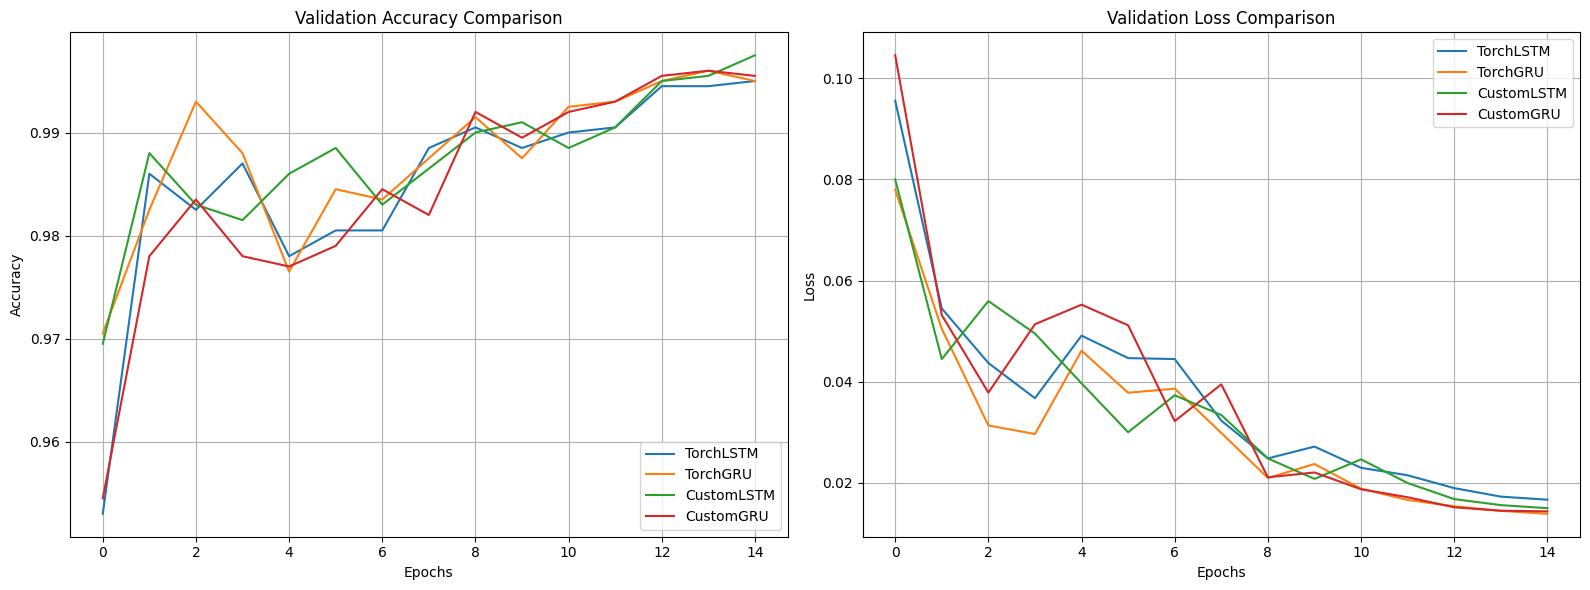

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for m_type in models_to_test:
    ax1.plot(results_history[m_type]['val_acc'], label=f'{m_type}')
ax1.set_title('Validation Accuracy Comparison')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

for m_type in models_to_test:
    ax2.plot(results_history[m_type]['val_loss'], label=f'{m_type}')
ax2.set_title('Validation Loss Comparison')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('metrics_comparison.png')
plt.show()

In [ ]:
test_sequences = [
    torch.ones(SEQ_LEN),
    -torch.ones(SEQ_LEN),
    torch.tensor([1.0 if i % 2 == 0 else -0.5 for i in range(SEQ_LEN)]),
    torch.tensor([-1.0 if i % 2 == 0 else 0.5 for i in range(SEQ_LEN)])
]

true_labels = ["Positive", "Negative", "Positive", "Negative"]

for m_type in models_to_test:
    model = SimpleClassifier(rnn_type=m_type).to(DEVICE)
    model.load_state_dict(torch.load(f'best_model_{m_type}.pth'))
    model.eval()

    for seq, true_lbl in zip(test_sequences, true_labels):
        seq_tensor = seq.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            outputs = model(seq_tensor)
            pred_idx = torch.argmax(outputs, dim=-1).item()

        pred_lbl = "Positive" if pred_idx == 1 else "Negative"

        print({
            'model': m_type,
            'sequence_preview': str(seq.numpy()[:3]) + "...",
            'true_label': true_lbl,
            'predicted_label': pred_lbl,
            'correct': true_lbl == pred_lbl
        })

{'model': 'TorchLSTM', 'sequence_preview': '[1. 1. 1.]...', 'true_label': 'Positive', 'predicted_label': 'Positive', 'correct': True}
{'model': 'TorchLSTM', 'sequence_preview': '[-1. -1. -1.]...', 'true_label': 'Negative', 'predicted_label': 'Negative', 'correct': True}
{'model': 'TorchLSTM', 'sequence_preview': '[ 1.  -0.5  1. ]...', 'true_label': 'Positive', 'predicted_label': 'Positive', 'correct': True}
{'model': 'TorchLSTM', 'sequence_preview': '[-1.   0.5 -1. ]...', 'true_label': 'Negative', 'predicted_label': 'Negative', 'correct': True}
{'model': 'TorchGRU', 'sequence_preview': '[1. 1. 1.]...', 'true_label': 'Positive', 'predicted_label': 'Positive', 'correct': True}
{'model': 'TorchGRU', 'sequence_preview': '[-1. -1. -1.]...', 'true_label': 'Negative', 'predicted_label': 'Negative', 'correct': True}
{'model': 'TorchGRU', 'sequence_preview': '[ 1.  -0.5  1. ]...', 'true_label': 'Positive', 'predicted_label': 'Positive', 'correct': True}
{'model': 'TorchGRU', 'sequence_preview':